## **GENERACIÓN DE FIGURAS PARA EL CAPÍTULO DE CONJUNTOS DE DATOS DE LA MEMORIA**

# Variación de resoluciones Kvasir-SEG

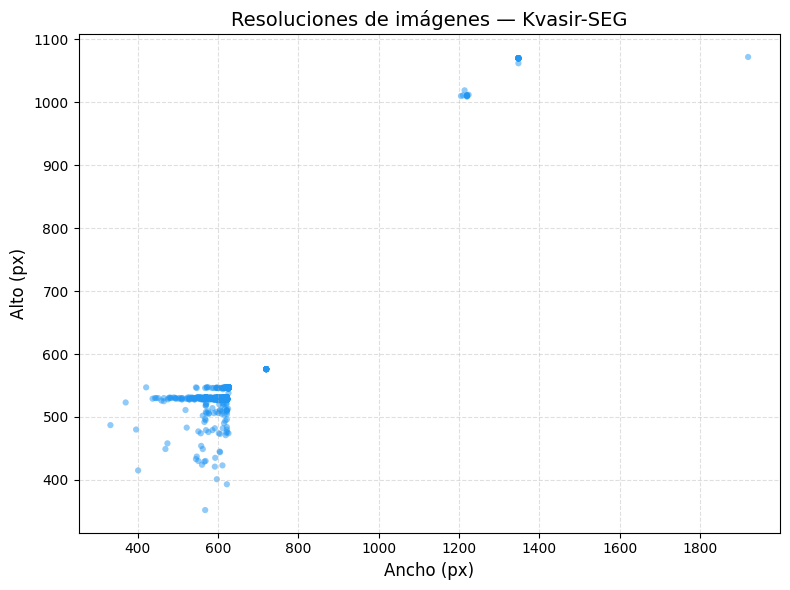

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\Kvasir-SEG\\images"

widths, heights = [], []

for fname in os.listdir(IMAGE_DIR):
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        with Image.open(os.path.join(IMAGE_DIR, fname)) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(widths, heights, alpha=0.5, s=20, color="#2196F3", edgecolors="none")

ax.set_xlabel("Ancho (px)", fontsize=12)
ax.set_ylabel("Alto (px)", fontsize=12)
ax.set_title("Resoluciones de imágenes — Kvasir-SEG", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("kvasir_seg_resolutions.png", dpi=150)
plt.show()

# Variación tamaños de los pólipos KVASIR-SEG

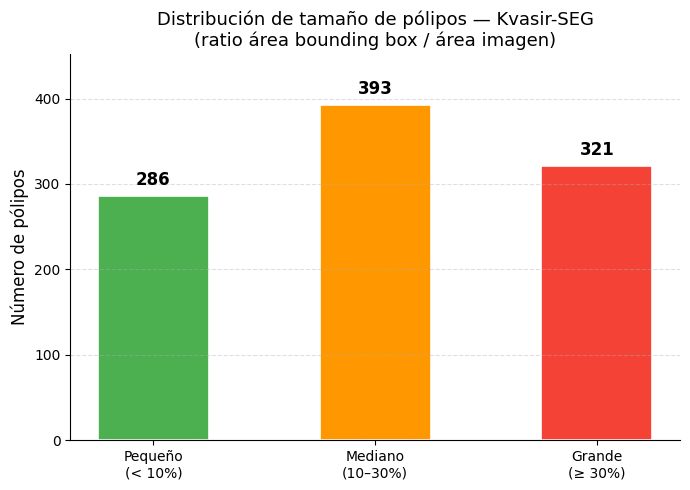

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\Kvasir-SEG\\images"
MASK_DIR  = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\Kvasir-SEG\\masks"

ratios = []

for fname in os.listdir(MASK_DIR):
    if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    mask = np.array(Image.open(os.path.join(MASK_DIR, fname)).convert("L"))
    rows = np.any(mask > 127, axis=1)
    cols = np.any(mask > 127, axis=0)

    if not rows.any():
        continue

    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]

    H, W = mask.shape
    bbox_area = (x_max - x_min) * (y_max - y_min)
    ratios.append(bbox_area / (W * H))

ratios = np.array(ratios)

small  = np.sum(ratios < 0.10)
medium = np.sum((ratios >= 0.10) & (ratios < 0.30))
large  = np.sum(ratios >= 0.30)

categories = ["Pequeño\n(< 10%)", "Mediano\n(10–30%)", "Grande\n(≥ 30%)"]
counts     = [small, medium, large]
colors     = ["#4CAF50", "#FF9800", "#F44336"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(categories, counts, color=colors, width=0.5, edgecolor="white", linewidth=1.2)

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        str(count),
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

ax.set_ylabel("Número de pólipos", fontsize=12)
ax.set_title("Distribución de tamaño de pólipos — Kvasir-SEG\n(ratio área bounding box / área imagen)", fontsize=13)
ax.set_ylim(0, max(counts) * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("kvasir_polyp_sizes.png", dpi=150)
plt.show()

# Pólipos, máscaras y bounding boxes KVASIR-SEG

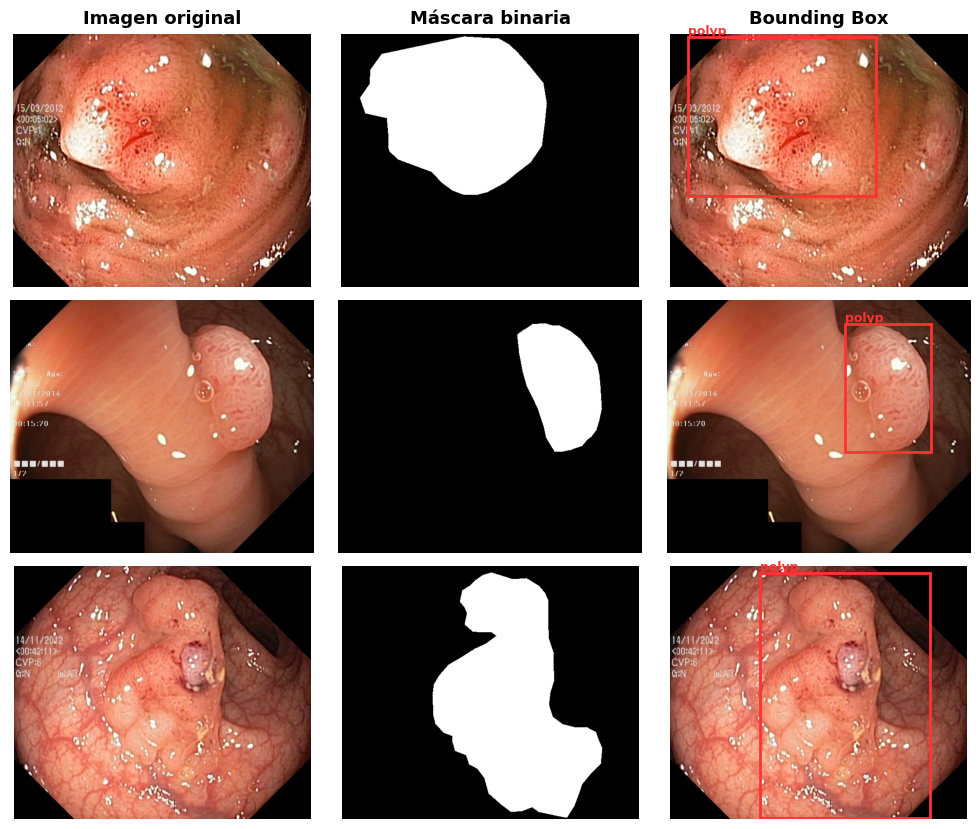

In [3]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

IMAGE_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\Kvasir-SEG\\images"
MASK_DIR  = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\Kvasir-SEG\\masks"

BBOXES = {
    "cju0qkwl35piu0993l0dewei2": {"height": 529, "width": 622,  "bbox": [{"label": "polyp", "xmin": 38,  "ymin": 5,   "xmax": 430, "ymax": 338}]},
    "cju5wtdu4m0im0871mix0yvc0": {"height": 509, "width": 610, "bbox": [{"label": "polyp", "xmin": 359, "ymin": 47, "xmax": 530, "ymax": 306}]},
    "cju0qx73cjw570799j4n5cjze": {"height": 529, "width": 619,  "bbox": [{"label": "polyp", "xmin": 187, "ymin": 14,   "xmax": 543, "ymax": 526}]},
}

ids = list(BBOXES.keys())
n   = len(ids)

fig, axes = plt.subplots(n, 3, figsize=(10, 2.8 * n))

col_titles = ["Imagen original", "Máscara binaria", "Bounding Box"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold", pad=8)

for row, img_id in enumerate(ids):
    img  = Image.open(os.path.join(IMAGE_DIR, f"{img_id}.jpg")).convert("RGB")
    mask = Image.open(os.path.join(MASK_DIR,  f"{img_id}.jpg")).convert("L")

    axes[row, 0].imshow(img)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(img)
    for bb in BBOXES[img_id]["bbox"]:
        x      = bb["xmin"]
        y      = bb["ymin"]
        width  = bb["xmax"] - bb["xmin"]
        height = bb["ymax"] - bb["ymin"]
        rect   = patches.Rectangle((x, y), width, height,
                                    linewidth=2, edgecolor="#FF3333", facecolor="none")
        axes[row, 2].add_patch(rect)
        axes[row, 2].text(x, y - 5, bb["label"],
                          color="#FF3333", fontsize=9, fontweight="bold")
    axes[row, 2].axis("off")


plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig("kvasir_muestras.png", dpi=150, bbox_inches="tight")
plt.show()

# VARIACIÓN DE RESOLUCIONES PASCAL-S

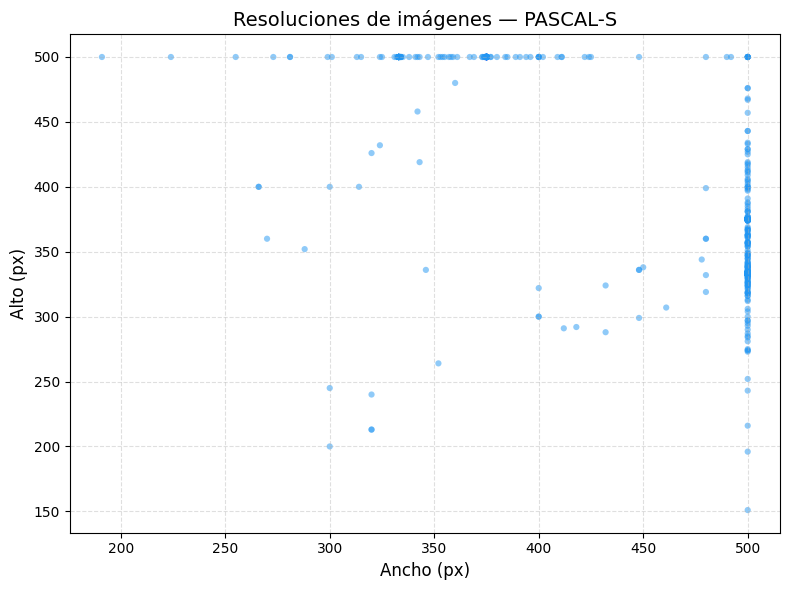

In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\PASCAL-S\\Test\\Image"

widths, heights = [], []

for fname in os.listdir(IMAGE_DIR):
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        with Image.open(os.path.join(IMAGE_DIR, fname)) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(widths, heights, alpha=0.5, s=20, color="#2196F3", edgecolors="none")

ax.set_xlabel("Ancho (px)", fontsize=12)
ax.set_ylabel("Alto (px)", fontsize=12)
ax.set_title("Resoluciones de imágenes — PASCAL-S", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("pascal_s_resolutions.png", dpi=150)
plt.show()

# Variación tamaños de los objetos salientes PASCAL-S

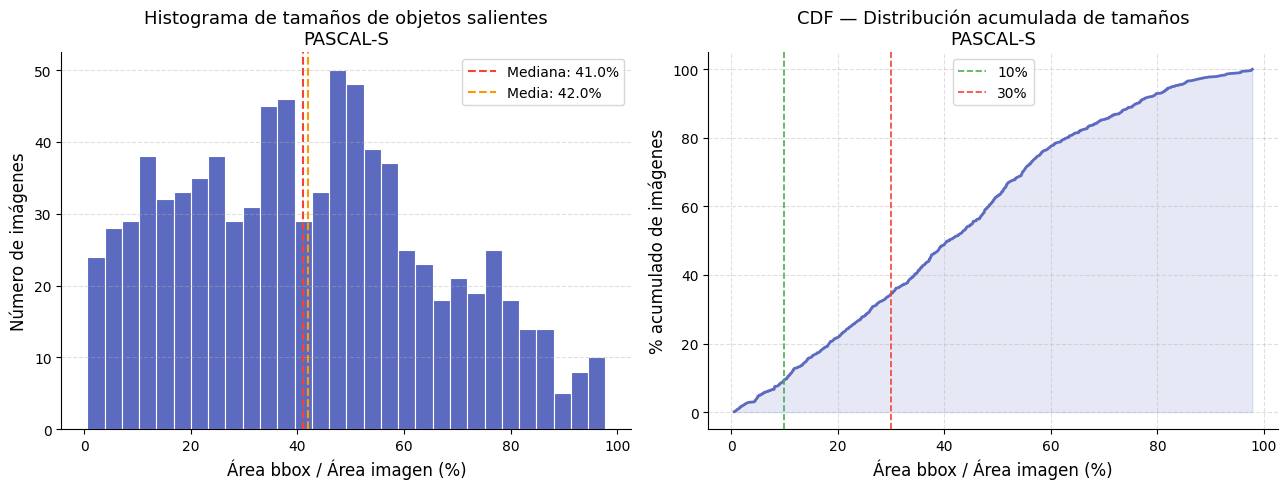

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\PASCAL-S\\Test\\Image"
MASK_DIR  = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\PASCAL-S\\Test\\GT"

ratios = []
for fname in os.listdir(MASK_DIR):
    if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
        continue
    mask = np.array(Image.open(os.path.join(MASK_DIR, fname)).convert("L"))
    rows = np.any(mask > 127, axis=1)
    cols = np.any(mask > 127, axis=0)
    if not rows.any():
        continue
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]
    H, W = mask.shape
    bbox_area = (x_max - x_min) * (y_max - y_min)
    ratios.append(bbox_area / (W * H))

ratios = np.array(ratios)
ratios_pct = ratios * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(ratios_pct, bins=30, color="#5C6BC0", edgecolor="white", linewidth=0.8)
axes[0].set_xlabel("Área bbox / Área imagen (%)", fontsize=12)
axes[0].set_ylabel("Número de imágenes", fontsize=12)
axes[0].set_title("Histograma de tamaños de objetos salientes\nPASCAL-S", fontsize=13)
axes[0].axvline(np.median(ratios_pct), color="#F44336", linestyle="--", linewidth=1.5, label=f"Mediana: {np.median(ratios_pct):.1f}%")
axes[0].axvline(np.mean(ratios_pct),   color="#FF9800", linestyle="--", linewidth=1.5, label=f"Media: {np.mean(ratios_pct):.1f}%")
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)

sorted_ratios = np.sort(ratios_pct)
cdf = np.arange(1, len(sorted_ratios) + 1) / len(sorted_ratios) * 100
axes[1].plot(sorted_ratios, cdf, color="#5C6BC0", linewidth=2)
axes[1].fill_between(sorted_ratios, cdf, alpha=0.15, color="#5C6BC0")
for thresh, color in [(10, "#4CAF50"), (30, "#F44336")]:
    axes[1].axvline(thresh, color=color, linestyle="--", linewidth=1.2, label=f"{thresh}%")
axes[1].set_xlabel("Área bbox / Área imagen (%)", fontsize=12)
axes[1].set_ylabel("% acumulado de imágenes", fontsize=12)
axes[1].set_title("CDF — Distribución acumulada de tamaños\nPASCAL-S", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(linestyle="--", alpha=0.4)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("pascal_salient_sizes.png", dpi=150)
plt.show()

# Objetos salientes, máscaras y bounding boxes PASCAL-S

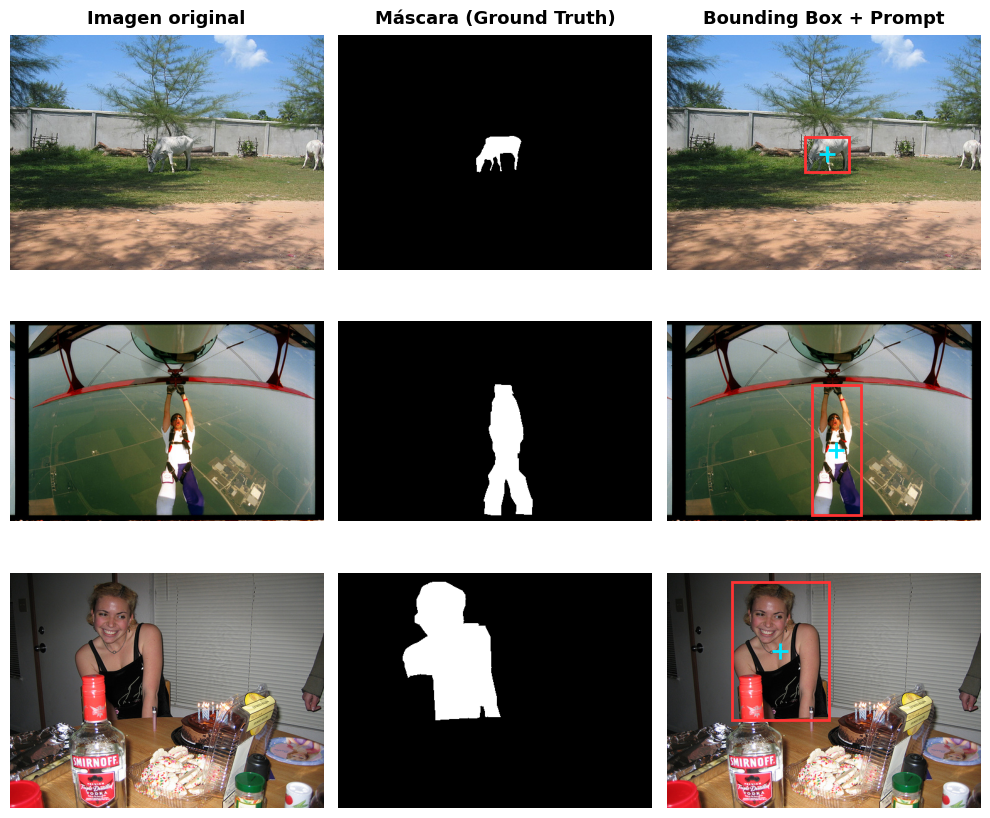

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

IMAGE_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\PASCAL-S\\Test\\Image"
MASK_DIR  = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\PASCAL-S\\Test\\GT"

all_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
selected  = all_files[:3]

fig, axes = plt.subplots(len(selected), 3, figsize=(10, 2.8 * len(selected)))

col_titles = ["Imagen original", "Máscara (Ground Truth)", "Bounding Box + Prompt"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold", pad=8)

for row, fname in enumerate(selected):
    base = os.path.splitext(fname)[0]

    img  = Image.open(os.path.join(IMAGE_DIR, fname)).convert("RGB")

    mask_path = os.path.join(MASK_DIR, base + ".png")
    if not os.path.exists(mask_path):
        mask_path = os.path.join(MASK_DIR, base + ".jpg")
    mask = Image.open(mask_path).convert("L")
    mask_np = np.array(mask)

    rows = np.any(mask_np > 127, axis=1)
    cols = np.any(mask_np > 127, axis=0)

    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]

    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2

    axes[row, 0].imshow(img)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask_np, cmap="gray")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(img)
    rect = patches.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=2, edgecolor="#FF3333", facecolor="none"
    )
    axes[row, 2].add_patch(rect)
    axes[row, 2].plot(cx, cy, "+", color="#00E5FF", markersize=12, markeredgewidth=2)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig("pascal_muestras.png", dpi=150, bbox_inches="tight")
plt.show()

# LONGITUDES FRASES REFCOCOG

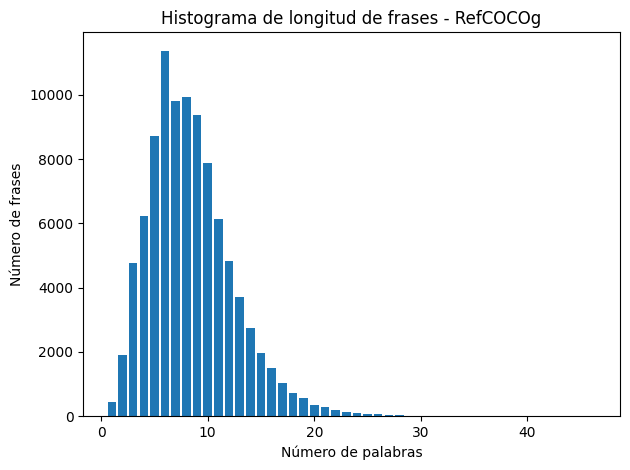

In [7]:
import json
from collections import Counter
import matplotlib.pyplot as plt

with open("C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\refcocog\\instances.json") as f:
    data = json.load(f)

with open("C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\refcocog\\refs(umd).p", "rb") as f:
    import pickle
    refs = pickle.load(f)

word_counts = Counter()
for ref in refs:
    for sentence in ref["sentences"]:
        n_words = len(sentence["sent"].split())
        word_counts[n_words] += 1

lengths = sorted(word_counts.keys())
counts = [word_counts[l] for l in lengths]

plt.bar(lengths, counts)
plt.xlabel("Número de palabras")
plt.ylabel("Número de frases")
plt.title("Histograma de longitud de frases - RefCOCOg")
plt.tight_layout()
plt.savefig("histograma.png", dpi=150)

# Muestras RefCOCOg

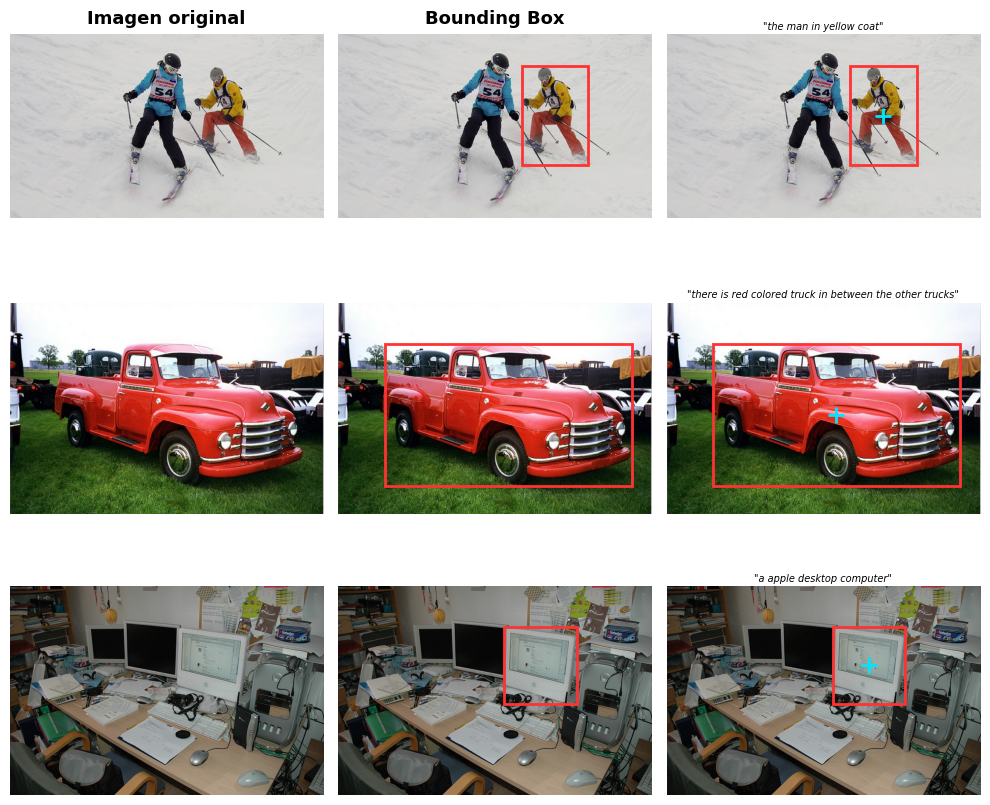

In [8]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

IMAGE_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\refcocog\\train2014"

with open("C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\refcocog\\refs(umd).p", "rb") as f:
    refs = pickle.load(f)

with open("C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\refcocog\\instances.json") as f:
    instances = json.load(f)

ann_map = {ann["id"]: ann for ann in instances["annotations"]}

selected = refs[:3]

fig, axes = plt.subplots(len(selected), 3, figsize=(10, 2.8 * len(selected)))

col_titles = ["Imagen original", "Bounding Box", "Bounding Box + Prompt"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold", pad=8)

for row, ref in enumerate(selected):
    file_name = f"COCO_train2014_{ref['image_id']:012d}.jpg"
    img = Image.open(os.path.join(IMAGE_DIR, file_name)).convert("RGB")

    ann = ann_map[ref["ann_id"]]
    x, y, w, h = ann["bbox"]
    cx, cy = x + w / 2, y + h / 2
    prompt = ref["sentences"][0]["sent"]

    axes[row, 0].imshow(img)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(img)
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="#FF3333", facecolor="none")
    axes[row, 1].add_patch(rect)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(img)
    rect2 = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="#FF3333", facecolor="none")
    axes[row, 2].add_patch(rect2)
    axes[row, 2].plot(cx, cy, "+", color="#00E5FF", markersize=12, markeredgewidth=2)
    axes[row, 2].set_title(f'"{prompt}"', fontsize=7, pad=4, style="italic")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.subplots_adjust(hspace=0.15)
plt.savefig("refcocog_muestras.png", dpi=150, bbox_inches="tight")
plt.show()


# ISIC 2016 RESOLUCIONES Y TAMAÑOS RELATIVOS

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\ISIC_2016"

SPLITS = {
    "Training": {
        "images": os.path.join(BASE_DIR, "ISBI2016_ISIC_Part1_Training_Data"),
        "masks":  os.path.join(BASE_DIR, "ISBI2016_ISIC_Part1_Training_GroundTruth"),
    },
    "Test": {
        "images": os.path.join(BASE_DIR, "ISBI2016_ISIC_Part1_Test_Data"),
        "masks":  os.path.join(BASE_DIR, "ISBI2016_ISIC_Part1_Test_GroundTruth"),
    },
}

anchos = []
altos  = []
tamanos_relativos = []
split_labels = []

for split_name, dirs in SPLITS.items():
    for filename in os.listdir(dirs["images"]):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(dirs["images"], filename)
        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]
        anchos.append(w)
        altos.append(h)
        split_labels.append(split_name)

        mask_name = os.path.splitext(filename)[0] + "_Segmentation.png"
        mask_path = os.path.join(dirs["masks"], mask_name)

        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                y_indices, x_indices = np.where(mask > 0)
                if len(x_indices) > 0:
                    x_min, x_max = np.min(x_indices), np.max(x_indices)
                    y_min, y_max = np.min(y_indices), np.max(y_indices)
                    area_bbox  = (x_max - x_min) * (y_max - y_min)
                    area_total = w * h
                    tamanos_relativos.append((area_bbox / area_total, split_name))

anchos       = np.array(anchos)
altos        = np.array(altos)
split_labels = np.array(split_labels)

colors = {"Training": "royalblue", "Test": "coral"}

plt.figure(figsize=(8, 6))
for split_name, color in colors.items():
    mask = split_labels == split_name
    plt.scatter(anchos[mask], altos[mask], alpha=0.5, color=color,
                edgecolor='k', label=split_name, s=30)
plt.title('Resolución espacial - ISIC 2016')
plt.xlabel('Ancho (píxeles)')
plt.ylabel('Alto (píxeles)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('resoluciones_isic.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(8, 6))
for split_name, color in colors.items():
    valores = [v for v, s in tamanos_relativos if s == split_name]
    plt.hist(valores, bins=30, color=color, edgecolor='k', alpha=0.7, label=split_name)
plt.title('Tamaño relativo de la Bounding Box - ISIC 2016')
plt.xlabel('Proporción (Área Bbox / Área Total)')
plt.ylabel('Número de imágenes')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('isic_sizes.png', dpi=300, bbox_inches='tight')
plt.close()


# Muestras visuales ISIC 2016

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


BASE_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\ISIC_2016"
SPLITS = {
    "Training": {
        "images": os.path.join(BASE_DIR, "ISBI2016_ISIC_Part1_Training_Data"),
        "masks":  os.path.join(BASE_DIR, "ISBI2016_ISIC_Part1_Training_GroundTruth"),
    },
    "Test": {
        "images": os.path.join(BASE_DIR, "ISBI2016_ISIC_Part1_Test_Data"),
        "masks":  os.path.join(BASE_DIR, "ISBI2016_ISIC_Part1_Test_GroundTruth"),
    },
}

IMAGES_DIR = SPLITS["Training"]["images"]
MASKS_DIR  = SPLITS["Training"]["masks"]
image_files = [f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg')][:3]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

for i, img_name in enumerate(image_files):
    img_path = os.path.join(IMAGES_DIR, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    mask_name = img_name.replace('.jpg', '_Segmentation.png')
    mask_path = os.path.join(MASKS_DIR, mask_name)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    y_indices, x_indices = np.where(mask > 0)
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    
    cx = int((x_min + x_max) / 2)
    cy = int((y_min + y_max) / 2)
    
    img_prompt = img.copy()
    cv2.rectangle(img_prompt, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4) # Caja Roja
    
    cross_size = 20
    cv2.line(img_prompt, (cx - cross_size, cy), (cx + cross_size, cy), (0, 255, 255), 4)
    cv2.line(img_prompt, (cx, cy - cross_size), (cx, cy + cross_size), (0, 255, 255), 4)

    axes[i, 0].imshow(img)
    axes[i, 0].axis('off')
    if i == 0: axes[i, 0].set_title('Imagen Original', fontsize=14, fontweight='bold')
        
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].axis('off')
    if i == 0: axes[i, 1].set_title('Máscara (Ground Truth)', fontsize=14, fontweight='bold')
        
    axes[i, 2].imshow(img_prompt)
    axes[i, 2].axis('off')
    if i == 0: axes[i, 2].set_title('Bounding Box y Centroide', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('isic_muestras.png', dpi=300, bbox_inches='tight')
plt.close()


# MAPILLARY VISTAS SIZES Y RESOLUCIONES

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

MASKS_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\Mapillary_Vistas\\validation\\instances"

anchos = []
altos = []
tamanos_relativos = []

for filename in os.listdir(MASKS_DIR):
    if filename.endswith(".png"):
        img_path = os.path.join(MASKS_DIR, filename)
        
        mask_16bit = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        if mask_16bit is None:
            continue
            
        h, w = mask_16bit.shape
        anchos.append(w)
        altos.append(h)
        area_total = w * h
        
        instancias_unicas = np.unique(mask_16bit)
        
        for id_instancia in instancias_unicas:
            if id_instancia > 65: 
                mascara_individual = (mask_16bit == id_instancia)
                
                y_indices, x_indices = np.where(mascara_individual)
                if len(x_indices) > 0 and len(y_indices) > 0:
                    x_min, x_max = np.min(x_indices), np.max(x_indices)
                    y_min, y_max = np.min(y_indices), np.max(y_indices)
                    
                    area_bbox = (x_max - x_min) * (y_max - y_min)
                    
                    if area_bbox > 50: 
                        tamanos_relativos.append(area_bbox / area_total)


plt.figure(figsize=(8, 6))
plt.scatter(anchos, altos, alpha=0.4, color='seagreen', edgecolor='k')
plt.title('Resolución espacial - Mapillary Vistas')
plt.xlabel('Ancho (píxeles)')
plt.ylabel('Alto (píxeles)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('resoluciones_mapillary.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(8, 6))
bins = np.logspace(np.log10(min(tamanos_relativos)), np.log10(max(tamanos_relativos)), 40)
plt.hist(tamanos_relativos, bins=bins, color='darkorange', edgecolor='k')
plt.xscale('log')
plt.title('Tamaño relativo de Instancias Urbanas')
plt.xlabel('Proporción (Área Bbox / Área Total) [Escala Log]')
plt.ylabel('Número de instancias')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('mapillary_sizes.png', dpi=300, bbox_inches='tight')
plt.close()


# MAPILLARY VISTAS MUESTRAS

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

IMAGES_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\Mapillary_Vistas\\validation\\images"
MASKS_DIR = "C:\\Users\\DanielTalavera\\Desktop\\Trabajo_Fin_de_Grado\\Mapillary_Vistas\\validation\\instances"

all_images = [f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg')]
selected_images = random.sample(all_images, 3)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

CLASES_OBJETIVO = [55, 19]

for i, img_name in enumerate(selected_images):
    img_path = os.path.join(IMAGES_DIR, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    mask_name = img_name.replace('.jpg', '.png')
    mask_path = os.path.join(MASKS_DIR, mask_name)
    mask_16bit = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    
    valores_unicos = np.unique(mask_16bit)
    
    best_mask = None
    bbox = None
    
    for val in valores_unicos:
        clase_id = val // 256
        
        if clase_id in CLASES_OBJETIVO:
            temp_mask = (mask_16bit == val)
            y_ind, x_ind = np.where(temp_mask)
            
            if len(x_ind) > 1000: 
                x_min, x_max = np.min(x_ind), np.max(x_ind)
                y_min, y_max = np.min(y_ind), np.max(y_ind)
                
                best_mask = temp_mask
                bbox = (x_min, y_min, x_max, y_max)
                break
                
    if best_mask is None:
        best_mask = np.zeros(mask_16bit.shape, dtype=np.uint8)

    img_prompt = img.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cx = int((x_min + x_max) / 2)
        cy = int((y_min + y_max) / 2)
        
        grosor = max(2, int(img.shape[0] * 0.005)) 
        cv2.rectangle(img_prompt, (x_min, y_min), (x_max, y_max), (255, 50, 50), grosor)
        
        cross_size = max(10, int(img.shape[0] * 0.02))
        cv2.line(img_prompt, (cx - cross_size, cy), (cx + cross_size, cy), (0, 255, 255), grosor)
        cv2.line(img_prompt, (cx, cy - cross_size), (cx, cy + cross_size), (0, 255, 255), grosor)

    axes[i, 0].imshow(img)
    axes[i, 0].axis('off')
    if i == 0: axes[i, 0].set_title('Imagen Urbana', fontsize=14, fontweight='bold')
        
    axes[i, 1].imshow(best_mask, cmap='gray')
    axes[i, 1].axis('off')
    if i == 0: axes[i, 1].set_title('Máscara Instancia (GT)', fontsize=14, fontweight='bold')
        
    axes[i, 2].imshow(img_prompt)
    axes[i, 2].axis('off')
    if i == 0: axes[i, 2].set_title('BBox y Centroide', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('mapillary_muestras_final.png', dpi=300, bbox_inches='tight')
plt.close()
